# Due to the large amount of data in the CIMA model testing dataset, we randomly sampled 5% of the data for Jupyter notebook testing, using the cMono_CD14 cell type. All the cMono_CD14 cell type testing dataset is stored in CIMA/datasets/tokenized_datasets/seq_dataset/hyenadna/cMono_CD14_all.

In [ ]:
import os

import sys
from typing import Any, Dict, List, Mapping, NewType
import logging
from pathlib import Path
import json
import math
import copy
import gc
from transformers import PreTrainedModel
import torch.nn as nn

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.utils.data
import transformers
import datasets
import evaluate
from tqdm import tqdm
from dataclasses import dataclass
import scanpy as sc

from sklearn.metrics import mean_squared_error
from scipy import stats

import time

from transformers import (
    HfArgumentParser,
    EvalPrediction,
    set_seed,
    TrainingArguments
)

from datasets import Dataset, DatasetDict, load_dataset, load_from_disk
from transformers.utils import check_min_version
from transformers.trainer_utils import get_last_checkpoint

sys.path.append("/CIMA/omiclm")

from omic_config import (
    OmicRawDataConfig,
    OmicPretrainedModelAndTokenizationConfig,
    OmicFormerTrainingArguments,
    OmicFormerTrainer,
)

from omic_models import (
    OmicFormerConfig, 
    OmicFormerPreTrainedModel,

    PretrainedModelName,
    PRETRAINED_MODEL_NAME_CLS_MAP,
    PRETRAINED_TOKENIZER_NAME_CLS_MAP,
)

from omic_dataset_collator import OmicDataset, OmicDataCollator

check_min_version("4.39.3")
logger = logging.getLogger(__name__)

sys.argv = [sys.argv[0]]  
parser = HfArgumentParser((
    OmicRawDataConfig, 
    OmicPretrainedModelAndTokenizationConfig, 
    OmicFormerTrainingArguments))
raw_data_config, pretrained_model_tokenizer_config, training_config = parser.parse_args_into_dataclasses()

# Setup logging
logging.basicConfig(
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    datefmt="%m/%d/%Y %H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
)

set_seed(training_config.seed)

if training_config.should_log:
    # The default of training_args.log_level is passive, 
    # so we set log level at info here to have that default.
    transformers.utils.logging.set_verbosity_info()

log_level = training_config.get_process_log_level() # log_level = 20
logger.setLevel(log_level)
datasets.utils.logging.set_verbosity(log_level)
transformers.utils.logging.set_verbosity(log_level)
transformers.utils.logging.enable_default_handler()
transformers.utils.logging.enable_explicit_format()

# Log on each process the small summary:
logger.warning(
    f"Process rank: {training_config.local_rank}, device: {training_config.device}, n_gpu: {training_config.n_gpu}, "
    + f"distributed training: {training_config.parallel_mode.value == 'distributed'}, 16-bits training: {training_config.fp16}"
)


/home/share/huadjyin/home/zhangxinyu4/.conda/envs/general-wyl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/share/huadjyin/home/zhangxinyu4/.conda/envs/general-wyl/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


04/17/2025 10:24:12 - WARNING - __main__ - Process rank: 0, device: cuda:0, n_gpu: 4, distributed training: False, 16-bits training: False


/home/share/huadjyin/home/zhangxinyu4/.conda/envs/general-wyl/lib/python3.9/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# Loading TOKENIZED SEQ dataset for prediction

In [2]:
with training_config.main_process_first(desc="loading seq data and model"):

    seq_tokenized_dataset_dir = pretrained_model_tokenizer_config.tokenized_seq_dataset_dir + f"/{raw_data_config.processed_cell_type_name}"
    logger.info(f">>> loading TOKENIZED SEQ data and split from {seq_tokenized_dataset_dir}")
        
    seq_hf_ds = load_from_disk(seq_tokenized_dataset_dir)

    tst_dataset = seq_hf_ds['test']
    logger.info(f"test dataset: \n{tst_dataset}")

04/17/2025 10:24:15 - INFO - __main__ - >>> loading TOKENIZED SEQ data and split from /home/share/huadjyin/home/zhangxinyu4/project/CIMA/datasets/tokenized_datasets/seq_dataset/hyenadna/cMono_CD14
04/17/2025 10:24:15 - INFO - __main__ - test dataset: 
Dataset({
    features: ['sample', 'pos', 'peak_value', 'sum_peak_value', 'record_id', 'input_ids', 'norm_peak_value', 'log1p_norm_peak_value'],
    num_rows: 337826
})


# Loading SCRNA EMBEDDING dataset for prediction

In [3]:
scrna_embedding_dataset_dir = os.path.join(pretrained_model_tokenizer_config.emb_scrna_dataset_dir, raw_data_config.processed_cell_type_name)
ac_data_file_name = os.path.join(scrna_embedding_dataset_dir, f"{raw_data_config.processed_cell_type_name}_embedding.h5ad")
logger.info(f">>> loading SCRNA EMBEDDING data (h5ad) from {ac_data_file_name}")
sc_adata = sc.read_h5ad(ac_data_file_name)

04/17/2025 10:24:20 - INFO - __main__ - >>> loading SCRNA EMBEDDING data (h5ad) from /home/share/huadjyin/home/zhangxinyu4/project/CIMA/datasets/embedding_datasets/scrna_dataset/scgpt/cMono_CD14/cMono_CD14_embedding.h5ad


# Integrating the embeddings from the DNA sequences and the single-cell gene expression matrix

In [4]:
tst_pt_ds: torch.utils.data.Dataset = OmicDataset(
    tst_dataset, 
    sc_adata,
    peak_value_feature=pretrained_model_tokenizer_config.peak_value_col_name,
)

# SEQ embedding model

In [5]:
logger.info(f">>> LOADED pretrained model and tokenizer from {pretrained_model_tokenizer_config.seq_model_path}")
seq_emb_model = (PRETRAINED_MODEL_NAME_CLS_MAP[
    pretrained_model_tokenizer_config.seq_model_name
    ].from_pretrained(pretrained_model_tokenizer_config.seq_model_path, use_cache=True)
) if not pretrained_model_tokenizer_config.seq_input_has_embedding else None
seq_emb_model.requires_grad_(False)

seq_input_pooling_size = 501    # max seq length for seq tokenized data of `input_ids`
scrna_input_pooling_size = 200  # pooling size of cell conts after scrna embeddings

omic_data_collator = OmicDataCollator(
    seq_pad_token_id=4, 
    sc_max_cnt=scrna_input_pooling_size, 
    seq_max_len=seq_input_pooling_size,
    seq_emb_model=seq_emb_model,
)
    
omic_model = OmicFormerPreTrainedModel.from_pretrained(
    pretrained_model_name_or_path=pretrained_model_tokenizer_config.omicformer_pretrained_model_dir,
    local_files_only=True,
        
    seq_emb_model=seq_emb_model,
    seq_emb_dim=pretrained_model_tokenizer_config.seq_model_d_dim,
    seq_emb_extraction_kwargs=None,

    scrna_emb_model=None,
    scrna_emb_dim=pretrained_model_tokenizer_config.scrna_model_d_dim, 
    scrna_emb_extraction_kwargs=None,
).to(training_config.device)

omic_model.config.use_cache = False
logger.info(f">>> OmicFormerPreTrainedModel: \n{omic_model}")
logger.info(f"num params: {omic_model.num_parameters()}")
logger.info(f"num trainable params: {omic_model.num_parameters(only_trainable=True)}")

data_loader = torch.utils.data.DataLoader(
    tst_pt_ds,
    batch_size=256,
    collate_fn=omic_data_collator,
    num_workers=3,
    pin_memory=True,
    drop_last=False,
)

omic_model.eval()
pred_results = dict(
    peak_value=[],
    pred_peak_value=[],
)

04/17/2025 10:24:37 - INFO - __main__ - >>> LOADED pretrained model and tokenizer from /home/share/huadjyin/home/zhangxinyu4/project/CIMA/HyenaDNA/hyenadna-medium-450k-seqlen


[INFO|configuration_utils.py:731] 2025-04-17 10:24:40,161 >> loading configuration file /home/share/huadjyin/home/zhangxinyu4/project/CIMA/omicformer_pretrained/cMono_CD14/config.json
[INFO|configuration_utils.py:800] 2025-04-17 10:24:40,164 >> Model config OmicFormerConfig {
  "dropout": 0.1,
  "ffn_type": "gated_mlp",
  "fusion_type": "cross_attn",
  "hidden_dim": 512,
  "initializer_range": 0.02,
  "intermediate_hidden_dim": 768,
  "model_type": "omicformer",
  "moe_topk": 2,
  "n_heads": 8,
  "n_layers_encoder": 4,
  "n_layers_fusion": 8,
  "n_outputs": 1,
  "n_residuals_per_layer": 2,
  "num_experts": 4,
  "out_pooling_mode": "adaptive",
  "out_pooling_size": 3,
  "pre_layer_type": "gated_mlp",
  "seq_input_pooling_size": 501,
  "transformers_version": "4.44.2",
  "use_cache": false
}

[INFO|modeling_utils.py:3675] 2025-04-17 10:24:40,166 >> loading weights file /home/share/huadjyin/home/zhangxinyu4/project/CIMA/omicformer_pretrained/cMono_CD14/pytorch_model.bin
/home/share/huadjy

04/17/2025 10:24:42 - INFO - __main__ - >>> OmicFormerPreTrainedModel: 
OmicFormerPreTrainedModel(
  (seq_emb_model): HyenaDNAPreTrainedModel(
    (model): HyenaDNAModel(
      (backbone): LMBackbone(
        (embeddings): GPT2Embeddings(
          (word_embeddings): Embedding(16, 256)
        )
        (layers): ModuleList(
          (0): Block(
            (mixer): HyenaOperator(
              (dropout): Dropout(p=0.0, inplace=False)
              (in_proj): Linear(in_features=256, out_features=768, bias=True)
              (out_proj): Linear(in_features=256, out_features=256, bias=True)
              (short_filter): Conv1d(768, 768, kernel_size=(3,), stride=(1,), padding=(2,), groups=768)
              (filter_fn): HyenaFilter(
                (dropout): Dropout(p=0.0, inplace=False)
                (pos_emb): PositionalEmbedding()
                (implicit_filter): Sequential(
                  (0): Linear(in_features=5, out_features=64, bias=True)
                  (1): Sin()
    

# Prediction

In [6]:
for batch in data_loader:

    seq_input_ids = batch['seq_input_ids'].to(training_config.device)
    seq_len = batch['seq_len'].to(training_config.device)
    cell_embedding = batch['cell_embedding'].to(training_config.device)
    with torch.no_grad():
        pred_out = omic_model(seq_input_ids=seq_input_ids, seq_len=seq_len, cell_embedding=cell_embedding)
        
    if isinstance(pred_out, tuple):
        pred_out = pred_out[0]
    elif isinstance(pred_out, Mapping):
        pred_out = pred_out['logits']

    pred_out = pred_out.squeeze().cpu().numpy().tolist()
    peak_value = batch['peak_value'].numpy().tolist()
    pred_results['peak_value'].extend(peak_value)
    pred_results['pred_peak_value'].extend(pred_out)
        

pred_results_dir = training_config.output_dir + '/prediction_501'
if not os.path.exists(pred_results_dir):
    os.makedirs(pred_results_dir, exist_ok=True)

with training_config.main_process_first(desc="clean scRNA cache files"):
    result_save_path = os.path.join(pred_results_dir, 'prediction_results.csv')
    logger.info(f">>> saving prediction results to {result_save_path}")
    pd.DataFrame.from_dict(pred_results, orient='columns').to_csv(result_save_path, index=False)
        
    seq_hf_ds.cleanup_cache_files()

logger.info("<<<<<<<<<<<<<<<<Done")

04/17/2025 10:39:22 - INFO - __main__ - >>> saving prediction results to /home/share/huadjyin/home/zhangxinyu4/project/CIMA/outputs_cMono_CD14/gated_mlp_mse/prediction_501/prediction_results.csv


Listing files in /home/share/huadjyin/home/zhangxinyu4/project/CIMA/datasets/tokenized_datasets/seq_dataset/hyenadna/cMono_CD14/train


04/17/2025 10:39:23 - INFO - datasets.arrow_dataset - Listing files in /home/share/huadjyin/home/zhangxinyu4/project/CIMA/datasets/tokenized_datasets/seq_dataset/hyenadna/cMono_CD14/train


Listing files in /home/share/huadjyin/home/zhangxinyu4/project/CIMA/datasets/tokenized_datasets/seq_dataset/hyenadna/cMono_CD14/test


04/17/2025 10:39:23 - INFO - datasets.arrow_dataset - Listing files in /home/share/huadjyin/home/zhangxinyu4/project/CIMA/datasets/tokenized_datasets/seq_dataset/hyenadna/cMono_CD14/test
04/17/2025 10:39:23 - INFO - __main__ - <<<<<<<<<<<<<<<<Done


# Calculating the PCC between observed and predicted values

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd
from datasets import load_from_disk

# Define a function to calculate the Pearson correlation coefficient for each sample group
def calculate_r_values(df):
    r_values = []
    for sample, group in df.groupby('sample'):
        r, _ = pearsonr(group['peak_value'], group['pred_peak_value'])
        r_values.append(r)
    return r_values

prediction_csv_path = '../outputs_cMono_CD14/gated_mlp_mse/prediction_501/prediction_results.csv'
dataset_path = '../datasets/tokenized_datasets/seq_dataset/hyenadna/cMono_CD14/test'

dataset = load_from_disk(dataset_path)
sample_column = dataset['sample']
sample_df = pd.DataFrame(sample_column, columns=['sample'])
df = pd.read_csv(prediction_csv_path)
df['sample'] = sample_df['sample']

r_values = calculate_r_values(df)
all_r_values = []
all_r_values.append(r_values)
r_values_df = pd.DataFrame(all_r_values).T
r_values_df.mean().iloc[0]

0.9740946243667246

# Box plot

/tmp/ipykernel_1235926/2106837692.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(**plot_param, ax=axs,palette=palette,size=1.5, zorder=2)
/tmp/ipykernel_1235926/2106837692.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axa = sns.boxplot(**plot_param,ax=axs,palette=palette, showfliers=False, linewidth=1, width=0.8, zorder=3)


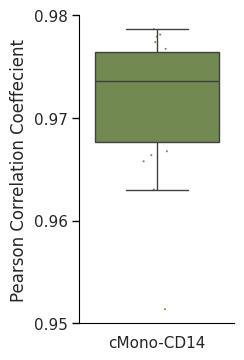

In [47]:
from statannotations.Annotator import Annotator
import numpy as np
from matplotlib.ticker import MaxNLocator

ds_contrib_df = pd.concat([pd.DataFrame({'feats':['cMono-CD14']*r_values_df.shape[0], 'contrib':r_values_df[0].values})])

orders = ['cMono-CD14']

palette = {'cMono-CD14':'#749248'}

colors = ['#749248']

fig, axs = plt.subplots(1,1, figsize=(2,4))

plot_param={
    'data':ds_contrib_df,
    'x':'feats',
    'y':'contrib',
    'order':orders,
    'orient':'v'
}

sns.stripplot(**plot_param, ax=axs,palette=palette,size=1.5, zorder=2)
axa = sns.boxplot(**plot_param,ax=axs,palette=palette, showfliers=False, linewidth=1, width=0.8, zorder=3)

for artist in axa.artists:
    artist.set_edgecolor('k')
    artist.set_alpha(0.8)

for i,artist in enumerate(axa.artists):
    # Set the linecolor on the artist to the facecolor, and set the facecolor to None
    col = artist.get_facecolor()
    artist.set_edgecolor(col)
    artist.set_facecolor('None')

    # Each box has 6 associated Line2D objects (to make the whiskers, fliers, etc.)
    # Loop over them here, and use the same colour as above
    for j in range(i*5,i*5+5):
        line = axa.lines[j]
        line.set_color(col)
        line.set_mfc(col)
        line.set_mec(col)

axa.set_xlabel('')
# axa.set_yticklabels(['{}%'.format(int(x*100)) for x in axa.get_yticks()]) 
#axa.set_yticklabels(['{:.3f}'.format(x) for x in axa.get_yticks()])
y_min, y_max = axa.get_ylim()
yticks_pos = np.linspace(y_min, y_max, 4)
axa.set_yticks(yticks_pos)
axa.set_yticklabels(['{:.2f}'.format(pos) for pos in yticks_pos])
axa.set_ylabel('Pearson Correlation Coeffecient')
sns.despine()
axa.set_facecolor('white')
axa.spines['top'].set_visible(False)
axa.spines['right'].set_visible(False)
axa.spines['left'].set_visible(True)
axa.spines['bottom'].set_visible(True)
for spine in axa.spines.values():
    spine.set_color('black')  
    spine.set_linewidth(0.8)  
axa.tick_params(
    axis='both',       
    which='both',        
    direction='out',      
    length=5,            
    width=1,           
    color='black',    
    bottom=False,       
    top=False,           
    left=True,           
    right=False            
)

# xticklabels = axa.set_xticklabels(axa.get_xticklabels(),rotation=0, ha='center',rotation_mode="anchor")
# for i, xticklabel in enumerate(xticklabels):
#     xticklabel.set_y(xticklabel.get_position()[1] +  0.01)

# for xtick, color in zip(axa.get_xticks(), colors):
#     axa.get_xticklabels()[xtick].set_color(color)
# axa.tick_params(direction='out', length=2, pad=1, width=1)


plt.grid(False)

plt.savefig("Pearson_Correlation_Coeffecient_cMono-CD14.pdf", dpi=400, bbox_inches='tight')